# 2.1
Zuerst wollte ich das threat_level vorhersagen, aber das hat nicht so funktioniert. Die Genauigkeit lag nie über 9%. Das Modell hat also einfach zufällig eine der 10 Stufen ausgewählt. 
Jetzt trainiere ich ein Modell, welches die Spalte "blocked" vorhersagen soll. Ich denke, das ist auch interessant, da man so ein Modell dazu verwenden kann, die Authorizationen zu überwachen und wenn nötig, zu blockieren.

# 2.2
Für folgende Felder werde ich relevante statische Informationen einfügen:

- success: Prozentanteile von erfolgreich und nicht erfolgreich
- failed_attempts: Durchschnitt und Median der Anzahl Fehlversuche
- session_duration: Druchschnitt und Median der Dauer
- suspicious_activity: Prozentanteil von verdächtig und unverdächtig
- blocked: Prozentanteil von geblockt und nicht geblockt

In [10]:
%pip install pandas

import pandas as pd
import os

data = pd.read_csv("archive/auth_authz_failures_dataset.csv")

#success
print(data["success"].value_counts(normalize=True) * 100)

#failed_attempts
print("\nfailed_attempts")
print("Median:",data["failed_attempts"].median())
print("Mean:",data["failed_attempts"].mean())

#session_duration
print("\nsession_duration")
print("Median:",data["session_duration"].median())
print("Mean:",data["session_duration"].mean())

#suspicious_activity
print()
print(data["suspicious_activity"].value_counts(normalize=True) * 100)

#blocked
print()
print(data["blocked"].value_counts(normalize=True) * 100)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
success
True     50.118
False    49.882
Name: proportion, dtype: float64

failed_attempts
Median: 5.0
Mean: 5.0013

session_duration
Median: 1806.0
Mean: 1809.4787

suspicious_activity
False    50.338
True     49.662
Name: proportion, dtype: float64

blocked
False    75.106
True     24.894
Name: proportion, dtype: float64


# 2.3

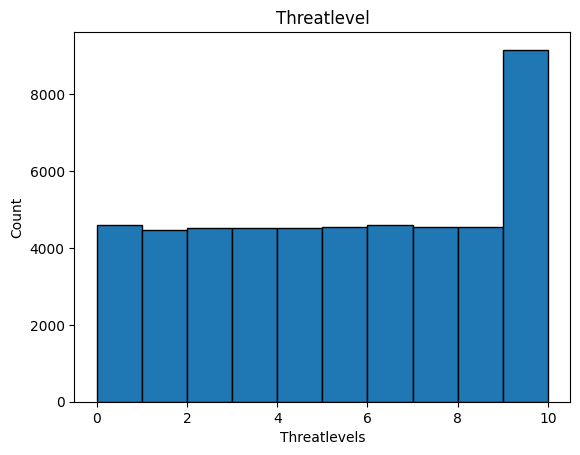

In [4]:
import matplotlib.pyplot as plt


plt.hist(data["threat_level"].dropna(), edgecolor="black")
plt.title("Threatlevel")
plt.xlabel("Threatlevels")
plt.ylabel("Count")

plt.show()

# 2.4
Ich benötige keine Skalierung, da ich den Random Forest verwende. Der Random Forest ist skalierungsunabhängig, da er mit Schwellenwerten und nicht mit Abständen arbeitet. Es spielt also für den Forest keine Rolle, ob die Zahlen skaliert oder ganz unterschiedlich sind. Das trifft auch auf die anderen Tree-Modelle zu.

# 3.1
Hier teile ich meinen Datensatz in einen test- und einen train-Satz ein. X sind die Spalten, welche für die Vorhersage verwendet werden und y ist die Spalte, welche vorhergesagt werden soll.

In [ ]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

X = data[["login_method", "success", "failure_reason", "auth_type", "account_status", "failed_attempts", "mfa_enabled", "token_expired", "session_duration", "suspicious_activity", "threat_level", "system_component", "error_code"]]
y = data["blocked"]

X = pd.get_dummies(X)
print(X.dtypes)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# 3.2
Ich verwende den Random Forest, da er gut mit gemischten Datentypen umgehen kann. Mit scikit-learn lässt er sich einfach implementieren und benötigt kaum Vorverarbeitung wie Skalierung. Zudem ist er robust gegen Ausreisser, da er viele Entscheidungsbäume kombiniert. Auch bei nichtlinearen Zusammenhängen zwischen Features liefert er zuverlässige Ergebnisse.

In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Note: you may need to restart the kernel to use updated packages.
success                               bool
failed_attempts                      int64
mfa_enabled                           bool
token_expired                         bool
session_duration                     int64
suspicious_activity                   bool
threat_level                         int64
login_method_API Key                  bool
login_method_MFA                      bool
login_method_Password                 bool
login_method_SSO                      bool
failure_reason_Account Locked         bool
failure_reason_Password Incorrect     bool
failure_reason_Token Expired          bool
auth_type_Biometric                   bool
auth_type_Password                    bool
auth_type_Token                       bool
account_status_Active                 bool
account_status_Locked                 bool
account_status_Suspended              bool
system_component_API Gateway          bool
system_component_Auth Server   


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy: 0.7535
              precision    recall  f1-score   support

       False       0.83      0.85      0.84      7576
        True       0.49      0.47      0.48      2424

    accuracy                           0.75     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.75      0.75      0.75     10000



# 3.3

In [12]:
y_pred = model.predict(X_test)

vergleich = X_test.copy()
vergleich["actual"] = y_test.values
vergleich["predicted"] = y_pred

print(vergleich.head(20))

       success  failed_attempts  mfa_enabled  token_expired  session_duration  \
36022     True                8         True           True              1224   
16139    False               10        False          False              3579   
42473     True               10        False           True              1519   
1714      True                1        False           True              1077   
22921     True                9        False           True              1872   
28020     True                3         True           True              2581   
28797     True                0         True          False              1859   
31393     True                8         True          False               383   
6788     False               10         True           True               629   
4730     False                8        False           True               657   
6115     False                9        False           True              2107   
23183     True              

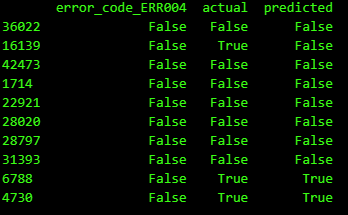
Hier kann man gut sehen, dass das Modell bei 10 Reihen recht genau ist. Von den 10 Beispielen hatte es nur eines falsch. Wenn man das aber auf 20 erhöht, hat mein Modell hier insgesammt fünf falsche Vorhersagen getroffen. Es ist allso nicht allzu gut und man könnte es sicher noch optimieren, aber es ist schon ganz ordentlich.

# 4.2

In [14]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

success                              0.199903
session_duration                     0.146735
failed_attempts                      0.091703
threat_level                         0.091505
failure_reason_Account Locked        0.037258
failure_reason_Token Expired         0.033689
failure_reason_Password Incorrect    0.029393
error_code_ERR004                    0.027584
error_code_ERR003                    0.026549
mfa_enabled                          0.025264
dtype: float64


# 4.3

In [16]:
y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
print()

TP = cm[1, 1]
FN = cm[1, 0]

sensitivity = TP / (TP + FN)
print("Sensitivity:", sensitivity)

print()

TN = cm[0, 0]
FP = cm[0, 1]

specificity = TN / (TN + FP)
print("specificity:", specificity)

[[6406 1170]
 [1295 1129]]

Sensitivity: 0.46575907590759075

specificity: 0.8455649419218585
